# Abdomen CT — **Faz 1a: Weak Segmentation Testi (BB → Semantik Maske)**

BB (bounding box) + Boundary Slice annotasyonlarından, katmanlı bir akışla semantik hastalık
maskesi üretimini test eder:

1. **TotalSegmentator** → anatomik organ maskesi (anatomik sınır)
2. **MedSAM** (box-prompt) → kutu içindeki lezyonun piksel-hassas sınırı
3. Organ maskesi ∩ MedSAM maskesi → nihai etiket (kesişim boşsa MedSAM, o da yoksa BB dikdörtgeni)
4. `kidney_ureter_stone` sınıfında ek olarak yüksek-HU (taş yoğunluğu, ≥150 HU) voksel eşiği

Bu notebook `src/weak_seg.py: generate_weak_masks()`'i **az sayıda vakada** (varsayılan 3)
hem eski davranışla (`use_medsam=False`, BB∩organ) hem yeni davranışla (`use_medsam=True`)
çalıştırıp sonuçları yan yana görselleştirir.

**Zorunlu Kaggle dataset:** `ramazan2020/abdomen` (ham DICOM + `Bilgi.xlsx`)

**GPU önerilir** (MedSAM + TotalSegmentator CPU'da da çalışır ama yavaştır).


---
## 0. Kaggle Kimlik Bilgisi (yalnızca Colab'da gerekli)

In [12]:
%matplotlib inline

In [1]:
import json
from pathlib import Path

# Yalnızca Colab'da, Kaggle API ile ham veriyi indirmek için gerekli.
# Kaggle'da native çalıştırırken bu hücreyi atlayabilirsiniz.
kaggle_json_content = """
{"username":"KULLANICI_ADINIZ","key":"API_ANAHTARINIZ"}
"""

KAGGLE_DIR = Path.home() / '.kaggle'
KAGGLE_JSON_PATH = KAGGLE_DIR / 'kaggle.json'
KAGGLE_DIR.mkdir(parents=True, exist_ok=True)

if "KULLANICI_ADINIZ" not in kaggle_json_content:
    json.loads(kaggle_json_content)  # gecerli JSON mu dogrula
    KAGGLE_JSON_PATH.write_text(kaggle_json_content.strip())
    KAGGLE_JSON_PATH.chmod(0o600)
    print(f"kaggle.json yazildi: {KAGGLE_JSON_PATH}")
else:
    print("kaggle.json atlandi (placeholder degistirilmedi) — Kaggle native ortaminda gerek yok.")


kaggle.json atlandi (placeholder degistirilmedi) — Kaggle native ortaminda gerek yok.


In [2]:
import os

IS_KAGGLE = os.path.exists('/kaggle/working')
IS_COLAB  = not IS_KAGGLE and os.path.exists('/content')
IS_LOCAL  = not IS_KAGGLE and not IS_COLAB

if IS_COLAB:
    # Ham DICOM + Bilgi.xlsx (Kaggle dataset: ramazan2020/abdomen)
    os.system("kaggle datasets download -d ramazan2020/abdomen -p /content/kaggle_data --unzip")


---
## 1. Ortam Tespiti + GPU

In [3]:
import sys, subprocess
from pathlib import Path

env_name = 'Kaggle' if IS_KAGGLE else 'Colab' if IS_COLAB else 'Local'
print(f'Ortam : {env_name}')

try:
    import torch
    if torch.cuda.is_available():
        print(f'GPU   : {torch.cuda.get_device_name(0)}  (CUDA)')
    elif torch.backends.mps.is_available():
        print('GPU   : Apple Silicon (MPS)')
    else:
        print('GPU   : yok — CPU\'de calisacak (MedSAM + TotalSegmentator yavas olur)')
except ImportError:
    print('torch henuz kurulu degil (bir sonraki hucrede kurulacak)')


Ortam : Local
GPU   : Apple Silicon (MPS)


---
## 2. Repo + Bağımlılıklar

In [4]:
GITHUB_URL = 'https://github.com/ramazan2020/abdomen1.git'

if IS_LOCAL:
    REPO_DIR = Path('.').resolve()
else:
    WORK_DIR = Path('/kaggle/working') if IS_KAGGLE else Path('/content')
    REPO_DIR = WORK_DIR / 'abdomen1'
    if not (REPO_DIR / '.git').exists():
        subprocess.run(['git', 'clone', '--depth=1', GITHUB_URL, str(REPO_DIR)], check=True)
    else:
        subprocess.run(['git', '-C', str(REPO_DIR), 'pull', '--ff-only'], capture_output=True)

if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

print(f'REPO_DIR: {REPO_DIR}')


REPO_DIR: /Users/ramazanpolat/Desktop/datasets/abdomen


In [5]:
# src/medsam_seg.py + weak_seg.py degisikliklerinin GitHub'a push edilmis olmasi gerekir
# (bu hucre repo'yu GITHUB_URL'den klonluyor/guncelliyor — yerel calismamis degisiklikleri gormez).
if not IS_LOCAL:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-e', f'{REPO_DIR}[ml]'], check=True)
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'TotalSegmentator'], check=True)
print('Bagimliliklar hazir.')


Bagimliliklar hazir.


---
## 3. Veri Yolları

In [6]:
import os

N_TEST_CASES = 3  # kac vaka test edilecek

if IS_KAGGLE:
    DATA_DIR    = Path('/kaggle/input/abdomen')
    EGITIM_DIR  = DATA_DIR / 'Egitim Verisi'
    YARISMA_DIR = DATA_DIR / 'Test Verisi'
    BILGI_XLSX  = DATA_DIR / 'Bilgi.xlsx'
    WORK_DIR    = Path('/kaggle/working')
elif IS_COLAB:
    DATA_DIR    = Path('/content/kaggle_data')
    EGITIM_DIR  = DATA_DIR / 'Egitim Verisi'
    YARISMA_DIR = DATA_DIR / 'Test Verisi'
    BILGI_XLSX  = DATA_DIR / 'Bilgi.xlsx'
    WORK_DIR    = Path('/content')
else:  # IS_LOCAL — gercek veri baska bir makinede/surucude ise ABDOMEN_* ile override edin
    DATA_DIR    = Path(os.environ.get('TR_ABDOMEN_BASE', r'D:/makale-pdf/Proje/abdomenDataSet'))
    EGITIM_DIR  = Path(os.environ.get('ABDOMEN_TRAIN_DIR', str(DATA_DIR / 'Egitim Verisi')))
    YARISMA_DIR = Path(os.environ.get('ABDOMEN_TEST_DIR',  str(DATA_DIR / 'Test Verisi')))
    BILGI_XLSX  = Path(os.environ.get('ABDOMEN_BILGI_XLSX', str(DATA_DIR / 'Bilgi.xlsx')))
    WORK_DIR    = Path(os.environ.get('ABDOMEN_OUT_DIR', str(REPO_DIR / 'outputs')))

# src/config.py bu degiskenleri import aninda okuyor -> src.* ilk import edilmeden once ayarla
os.environ['ABDOMEN_TRAIN_DIR']  = str(EGITIM_DIR)
os.environ['ABDOMEN_TEST_DIR']   = str(YARISMA_DIR)
os.environ['ABDOMEN_BILGI_XLSX'] = str(BILGI_XLSX)
os.environ['ABDOMEN_OUT_DIR']    = str(WORK_DIR)

for name, p in [('EGITIM_DIR', EGITIM_DIR), ('YARISMA_DIR', YARISMA_DIR), ('BILGI_XLSX', BILGI_XLSX)]:
    print(f'{name:12s}: {p}  (var={p.exists()})')

if not (EGITIM_DIR.exists() or YARISMA_DIR.exists()):
    raise FileNotFoundError(
        'Ham DICOM verisi bulunamadi. Kaggle: sag panelden "abdomen" dataset\'ini ekleyin. '
        'Colab: yukaridaki kaggle indirme hucresini calistirin.'
    )


EGITIM_DIR  : /Users/ramazanpolat/Desktop/datasets/abdomenDataSet/Egitim Verisi  (var=True)
YARISMA_DIR : /Users/ramazanpolat/Desktop/datasets/abdomenDataSet/Test Verisi  (var=True)
BILGI_XLSX  : /Users/ramazanpolat/Desktop/datasets/abdomenDataSet/Bilgi.xlsx  (var=True)


In [7]:
from src.config import SPLIT_DIR

manifest_csv = SPLIT_DIR / 'manifest.csv'
if not manifest_csv.exists():
    print('manifest.csv bulunamadi, uretiliyor (Bilgi.xlsx\'ten)...')
    from src.preprocessing import build_manifest
    build_manifest(manifest_csv)
print(f'manifest.csv: {manifest_csv}  ({manifest_csv.stat().st_size/1e3:.0f} KB)')


manifest.csv: /Users/ramazanpolat/Desktop/datasets/abdomen/outputs/splits/manifest.csv  (5083 KB)


---
## 4. Weak Segmentation — Baseline (BB ∩ Organ) vs MedSAM+HU Rafinaj

Aynı `N_TEST_CASES` vaka üzerinde iki modu da çalıştırıp karşılaştırıyoruz:
- **baseline**: `use_medsam=False` → eski davranış, BB dikdörtgeni ∩ organ maskesi
- **medsam**: `use_medsam=True` → MedSAM(BB) ∩ organ maskesi + taş sınıfında HU eşiği


In [8]:
from src.weak_seg import generate_weak_masks

OUT_BASELINE = WORK_DIR / 'weak_masks_baseline'
OUT_MEDSAM   = WORK_DIR / 'weak_masks_medsam'

print('=== Baseline (BB ∩ organ, MedSAM kapali) ===')
generate_weak_masks(limit=N_TEST_CASES, out_dir=OUT_BASELINE, use_medsam=False)


=== Baseline (BB ∩ organ, MedSAM kapali) ===
Cihaz: mps
BB annotasyonlu vaka: 3  |  işlenecek: 3
DICOM→NIfTI paralel dönüşüm (4 worker)...


TotalSeg+Maske: 100%|██████████| 3/3 [01:18<00:00, 26.29s/it]



Sınıf voxel sayıları:
  acute_cholecystitis                : 0
  kidney_ureter_stone                : 0
  acute_pancreatitis                 : 0
  aortic_aneurysm_dissection         : 0
  acute_appendicitis                 : 11,543
  acute_diverticulitis               : 0

Bitti — işlenen: 1, atlanan: 2
Maskeler: /Users/ramazanpolat/Desktop/datasets/abdomen/outputs/weak_masks_baseline


In [9]:
print('=== MedSAM + organ + HU rafinaji ===')
generate_weak_masks(limit=N_TEST_CASES, out_dir=OUT_MEDSAM, use_medsam=True)


=== MedSAM + organ + HU rafinaji ===
Cihaz: mps
BB annotasyonlu vaka: 3  |  işlenecek: 3
DICOM→NIfTI paralel dönüşüm (4 worker)...


TotalSeg+Maske:   0%|          | 0/3 [00:00<?, ?it/s]/Users/ramazanpolat/Desktop/datasets/abdomen/.venv/lib/python3.9/site-packages/pydicom/pixel_data_handlers/numpy_handler.py:250: UserWarning: The length of the pixel data in the dataset (1048576 bytes) indicates it contains excess padding. 524288 bytes will be removed from the end of the data
  warnings.warn(msg)
TotalSeg+Maske:  33%|███▎      | 1/3 [00:13<00:27, 13.81s/it]

  [uyari] MedSAM basarisiz (z=175): Cannot convert a MPS Tensor to float64 dtype as the MPS framework doesn't support float64. Please use float32 instead.
  [uyari] MedSAM basarisiz (z=176): Cannot convert a MPS Tensor to float64 dtype as the MPS framework doesn't support float64. Please use float32 instead.
  [uyari] MedSAM basarisiz (z=177): Cannot convert a MPS Tensor to float64 dtype as the MPS framework doesn't support float64. Please use float32 instead.
  [uyari] MedSAM basarisiz (z=178): Cannot convert a MPS Tensor to float64 dtype as the MPS framework doesn't support float64. Please use float32 instead.
  [uyari] MedSAM basarisiz (z=179): Cannot convert a MPS Tensor to float64 dtype as the MPS framework doesn't support float64. Please use float32 instead.
  [uyari] MedSAM basarisiz (z=180): Cannot convert a MPS Tensor to float64 dtype as the MPS framework doesn't support float64. Please use float32 instead.
  [uyari] MedSAM basarisiz (z=181): Cannot convert a MPS Tensor to flo

TotalSeg+Maske:  67%|██████▋   | 2/3 [00:54<00:29, 29.82s/it]

  [uyari] MedSAM basarisiz (z=189): Cannot convert a MPS Tensor to float64 dtype as the MPS framework doesn't support float64. Please use float32 instead.
  [uyari] MedSAM basarisiz (z=190): Cannot convert a MPS Tensor to float64 dtype as the MPS framework doesn't support float64. Please use float32 instead.
  [uyari] MedSAM basarisiz (z=191): Cannot convert a MPS Tensor to float64 dtype as the MPS framework doesn't support float64. Please use float32 instead.
  [uyari] MedSAM basarisiz (z=192): Cannot convert a MPS Tensor to float64 dtype as the MPS framework doesn't support float64. Please use float32 instead.


TotalSeg+Maske: 100%|██████████| 3/3 [01:20<00:00, 26.94s/it]



Sınıf voxel sayıları:
  acute_cholecystitis                : 0
  kidney_ureter_stone                : 0
  acute_pancreatitis                 : 0
  aortic_aneurysm_dissection         : 0
  acute_appendicitis                 : 29,026
  acute_diverticulitis               : 0

Bitti — işlenen: 1, atlanan: 2
Maskeler: /Users/ramazanpolat/Desktop/datasets/abdomen/outputs/weak_masks_medsam


---
## 5. Görsel Karşılaştırma (BB'li kesitler)

Gorsellestirilecek vaka (numerik id): 20003


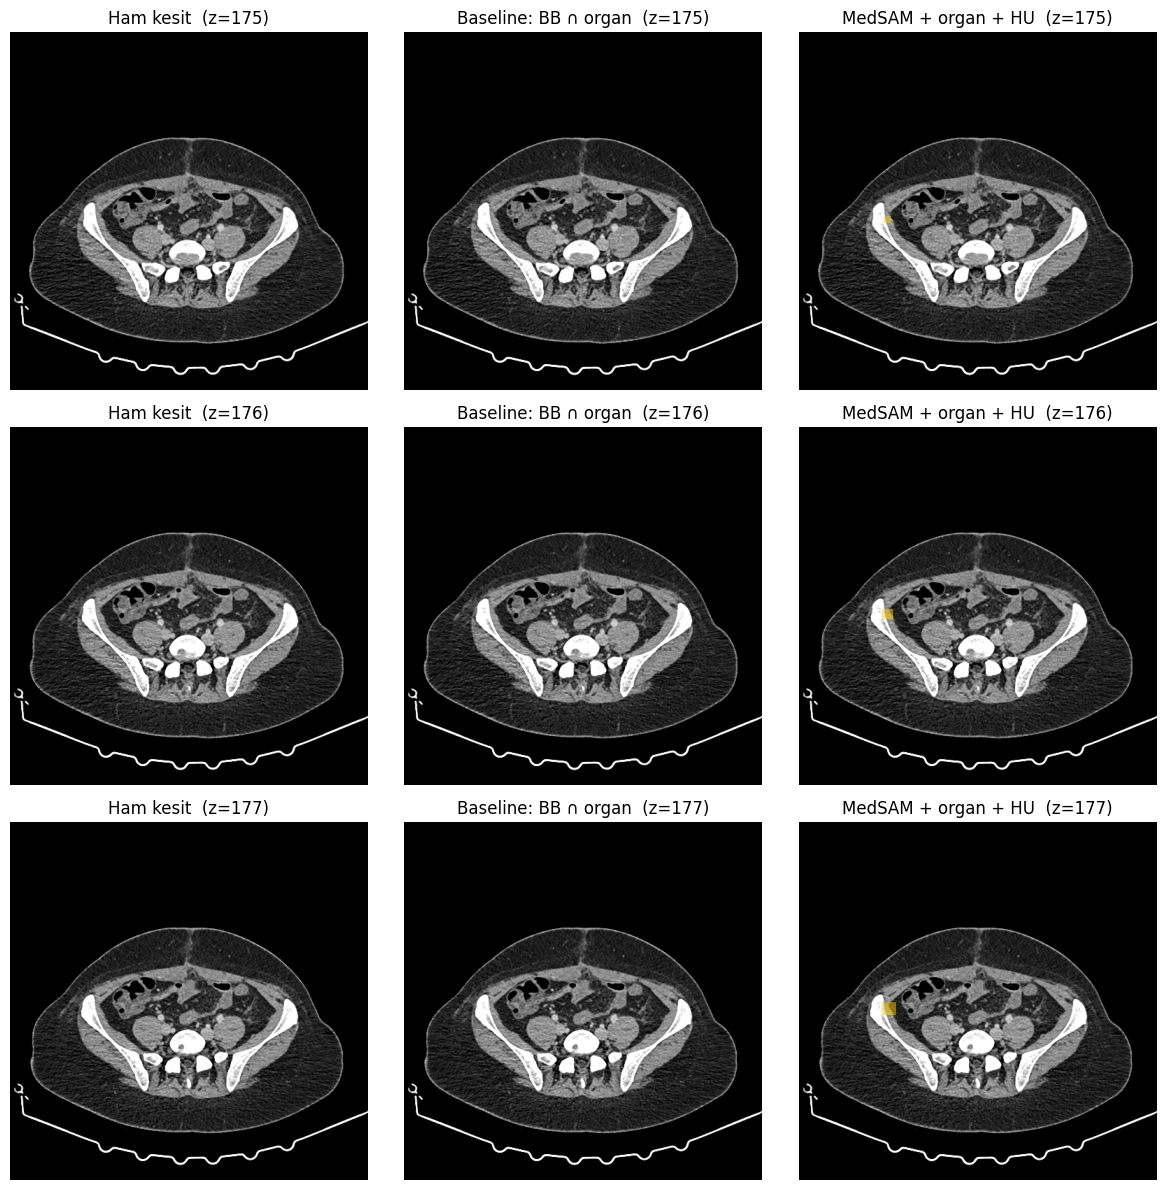

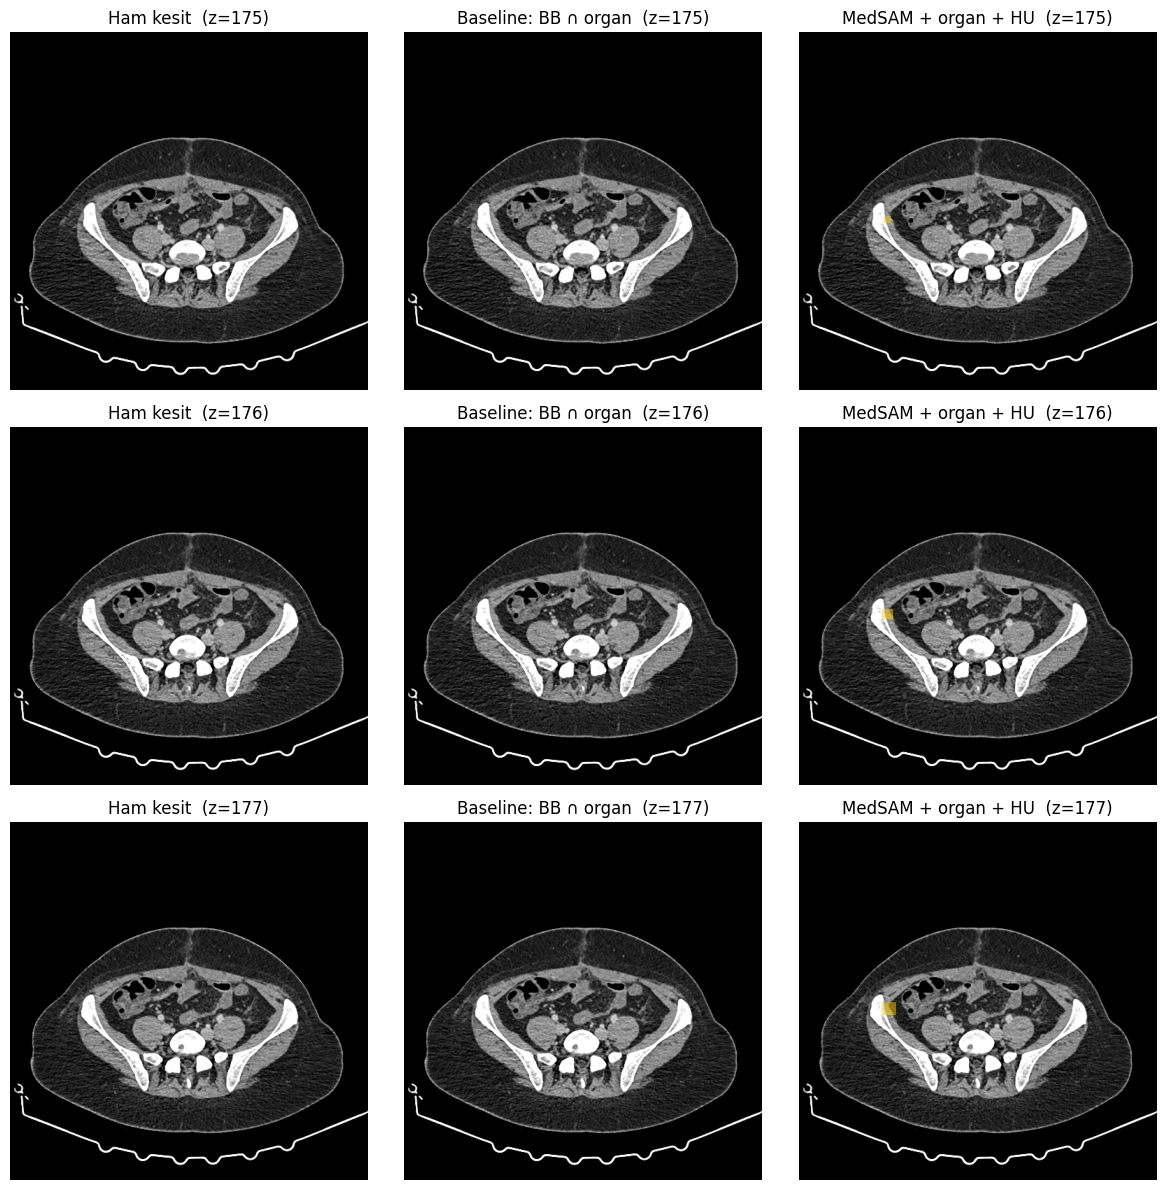

In [13]:
import numpy as np
import pandas as pd
import SimpleITK as sitk
import matplotlib.pyplot as plt

from src.config import DEFAULT_WINDOWS
from src.dicom_utils import load_series, window_hu
from src.splits import raw_case_id

manifest = pd.read_csv(manifest_csv)
bb_rows  = manifest[manifest['bboxes'].fillna('') != '']

# baseline ciktisi olan ilk vakayi bul (ayni case medsam ciktisinda da olmali)
# Dosya adlari numerik id kullanir (ABE_<numerik>_disease.nii.gz); manifest'teki
# "case" sutunu ise T_/C_ onekli string'dir (raw_case_id ile eslenir).
disease_files = sorted(OUT_BASELINE.glob('ABE_*_disease.nii.gz'))
if not disease_files:
    raise RuntimeError('Hic maske uretilmedi — yukaridaki hucre ciktisini kontrol edin.')

case_num = int(disease_files[0].stem.split('_')[1])
print(f'Gorsellestirilecek vaka (numerik id): {case_num}')

case_dir = next(b / str(case_num) for b in (EGITIM_DIR, YARISMA_DIR) if (b / str(case_num)).is_dir())
series   = load_series(case_dir)

mask_base = sitk.GetArrayFromImage(sitk.ReadImage(str(OUT_BASELINE / f'ABE_{case_num:05d}_disease.nii.gz')))
mask_med  = sitk.GetArrayFromImage(sitk.ReadImage(str(OUT_MEDSAM   / f'ABE_{case_num:05d}_disease.nii.gz')))

case_bb = bb_rows[bb_rows['case'].apply(raw_case_id) == case_num]
zs = sorted({series.image_ids.index(int(r.image_id)) for r in case_bb.itertuples()
             if int(r.image_id) in series.image_ids})[:3]

fig, axes = plt.subplots(len(zs), 3, figsize=(12, 4 * len(zs)))
if len(zs) == 1:
    axes = axes[None, :]

for row, z in enumerate(zs):
    gray = window_hu(series.hu[z], DEFAULT_WINDOWS[0])
    for col, (title, mask) in enumerate([
        ('Ham kesit', None),
        ('Baseline: BB ∩ organ', mask_base[z]),
        ('MedSAM + organ + HU', mask_med[z]),
    ]):
        ax = axes[row, col]
        ax.imshow(gray, cmap='gray')
        if mask is not None:
            overlay = np.ma.masked_where(mask == 0, mask)
            ax.imshow(overlay, cmap='autumn', alpha=0.5, vmin=1, vmax=6)
        ax.set_title(f'{title}  (z={z})')
        ax.axis('off')

plt.tight_layout()
plt.show()


---
## 6. Voksel İstatistikleri Karşılaştırması

In [14]:
import json as _json

for label, out_dir in [('baseline', OUT_BASELINE), ('medsam', OUT_MEDSAM)]:
    stats_path = out_dir / 'stats.json'
    if stats_path.exists():
        stats = _json.loads(stats_path.read_text())
        print(f'--- {label} ---')
        for cls, n in stats['voxel_counts'].items():
            print(f'  {cls:35s}: {n:,}')
    else:
        print(f'{label}: stats.json bulunamadi ({stats_path})')


--- baseline ---
  acute_cholecystitis                : 0
  kidney_ureter_stone                : 0
  acute_pancreatitis                 : 0
  aortic_aneurysm_dissection         : 0
  acute_appendicitis                 : 11,543
  acute_diverticulitis               : 0
--- medsam ---
  acute_cholecystitis                : 0
  kidney_ureter_stone                : 0
  acute_pancreatitis                 : 0
  aortic_aneurysm_dissection         : 0
  acute_appendicitis                 : 29,026
  acute_diverticulitis               : 0
